# E2 — ISIC 2017 UNet2D Architecture Tie-Break (10 seeds)

**Question.** Between `classical + he2` (HE2) and `classical + attention_gate` (AG) (both at `lr = 3e-4`), which architecture produces the better segmentation model?

**Design.** 10 shared seeds (100–109). Within each seed both architectures share weight initialisation and data ordering, so the *only* difference inside a seed pair is the architecture. We therefore analyse the **paired** differences Δᵢ = AGᵢ − HE2ᵢ using ISIC 2017 validation set

**Source.** `E2-isic2017-unet2d-model-tiebreak-5seed.db` (seeds 100–104) + `…_part2.db` (seeds 105–109) — 20 runs (2 architectures × 10 seeds), all `FINISHED`.

## Executive summary

- Paired across 10 shared seeds, Δ = AG − HE2
- Primary test = Wilcoxon signed-rank
- CI = BCa bootstrap 95 % (10 000 resamples, `rng=42`)
- d_z = Cohen's paired effect size.

| Metric | AG | HE2 | Δ (AG−HE2) | 95 % BCa CI | Wilcoxon p | d_z | Verdict |
|---|---|---|---|---|---|---|---|
| **Plateau Dice** — *primary, pre-registered* [1] | 0.8300 | 0.8275 | **+0.0025** | [+0.0006, +0.0048] | **0.037** | +0.70 | **AG** ✓ |
| Peak Dice | 0.8458 | 0.8464 | −0.0006 | [−0.0024, +0.0009] | 0.70 | −0.20 | tie |
| Peak IoU | 0.7392 | 0.7397 | −0.0005 | [−0.0035, +0.0022] | 0.85 | −0.10 | tie |
| Generalisation gap *(lower = better)* | 0.0921 | 0.0945 | −0.0024 | [−0.0068, +0.0030] | 0.38 | −0.29 | tie |
| Throughput [2] | 119.7 sps | 135.3 sps | −15.6 (−13 %) | [−17.3, −12.7] | **0.002** | −4.1 | **HE2** ✓ |

[1] Plateau Dice is the primary metrics; tested standalone (k = 1, α = 0.05).  

Secondary quality metrics: Peak Dice, Peak IoU and Gen-gap form a Holm family (k = 3) — none of the paired differences are significant.

[2] Training-cost hypothesis; standalone (k = 1, α = 0.05).

**Finding.** 
- AG wins on the pre-registered primary metric (plateau Dice: p = 0.037, CI excludes 0, d_z = +0.70, 8 out of 10 seeds)
- Peak Dice and IoU are statistical ties (|Δ| < 0.001, p > 0.7)
- HE2 trains 13 % faster (p=0.002)

**Decision: lock `classical + attention_gate` at `lr = 3e-4`.** 

In [1]:
# ── Path bootstrap (must run before any SkiNet import) ───────────────────────
import sys
from pathlib import Path

# Resolve the repo root regardless of kernel working directory.
# VS Code injects __vsc_ipynb_file__; nbconvert sets CWD = notebook directory.
try:
    _nb_dir = Path(__vsc_ipynb_file__).resolve().parent  # VS Code interactive
except NameError:
    _nb_dir = Path().resolve()                            # nbconvert / CLI

PROJECT_ROOT = _nb_dir.parents[1].resolve()
sys.path.insert(0, str(PROJECT_ROOT))

# ── Imports ───────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

from SkiNet.Utils.analysis.aggregation import load_runs
from SkiNet.Utils.analysis.stats import build_comparison_table
from SkiNet.Utils.analysis.reporting import show_run_table, show_comparison_table, show_family_verdicts
from SkiNet.Utils.analysis.plotting import set_paper_style, plot_paired_slopegraph, plot_paired_forest
from SkiNet.Utils.analysis.schema import VAL_DICE_MAX, VAL_DICE_TAIL_MEAN, VAL_IOU_MAX, GENERALIZATION_GAP_FINAL, SAMPLES_PER_SEC

# ── Configuration — every tunable argument lives in this cell ────────────────
FIG_DIR  = _nb_dir / '_static/model_selection'
DB_PATHS = [
    PROJECT_ROOT / 'mlruns' / 'E2-isic2017-unet2d-model-tiebreak-5seed.db',        # seeds 100–104
    PROJECT_ROOT / 'mlruns' / 'E2-isic2017-unet2d-model-tiebreak-5seed_part2.db',  # seeds 105–109
]

AG, HE2 = 'classical+attention_gate', 'classical+he2'
EXPERIMENT_MAP = {1: HE2, 2: AG} # MLflow experiment_id  -  architecture
PALETTE = {AG: '#d1495b', HE2: '#30638e'} # color palette for the two architectures

ALPHA   = 0.05 # significance level for confidence intervals and hypothesis tests
N_BOOT  = 10_000 # bootstrap samples for confidence intervals and p-values
RNG     = np.random.default_rng(42) # random number generator for reproducibility

# Metric column names are imported from SkiNet.Utils.analysis.schema; the
# spec lists below stay here because the choice of metrics, family sizes and
# display names is specific to this E2 paired comparison.
PRIMARY_METRIC    = VAL_DICE_TAIL_MEAN
SECONDARY_METRICS = [VAL_DICE_MAX, VAL_IOU_MAX, GENERALIZATION_GAP_FINAL]
# (metric, higher_is_better, family_size_k)
METRICS_SPEC = [
    (VAL_DICE_MAX,             True,  len(SECONDARY_METRICS)),
    (VAL_IOU_MAX,              True,  len(SECONDARY_METRICS)),
    (VAL_DICE_TAIL_MEAN,       True,  1),
    (GENERALIZATION_GAP_FINAL, False, len(SECONDARY_METRICS)),
    (SAMPLES_PER_SEC,          True,  1),
]
SLOPE_METRICS = [
    (VAL_DICE_MAX,       'Peak Dice (best checkpoint)'),
    (VAL_DICE_TAIL_MEAN, 'Plateau Dice (last-10-epoch mean)'),
]
# (display_name, metric, higher_is_better)
FOREST_SPECS = [
    ('Peak Dice',         VAL_DICE_MAX,             False),
    ('Peak IoU',          VAL_IOU_MAX,              False),
    ('Plateau Dice',      VAL_DICE_TAIL_MEAN,       False),
    ('Gen-gap reduction', GENERALIZATION_GAP_FINAL, True),
]

# ── Presentation ─────────────────────────────────────────────────────────────
set_paper_style(context='notebook')
pd.set_option('display.width', 220)
pd.set_option('display.float_format', '{:.4f}'.format)

In [2]:

# ── Load: 20 runs = 2 architectures × 10 seeds ───────────────────────────────
runs = load_runs(*DB_PATHS, exp_map=EXPERIMENT_MAP, monitor="val_dice")
SEEDS, N = sorted(runs['seed'].unique()), runs['seed'].nunique()

Loaded 20 runs: {'classical+he2': 10, 'classical+attention_gate': 10} | seeds: [100, 101, 102, 103, 104, 105, 106, 107, 108, 109]


## 1. Data

One row per (seed, architecture). Columns:

- **`val_dice_max`** — peak Dice of the best-saved checkpoint (the model that would actually be deployed).
- **`val_dice_tail_mean` / `…_std`** — mean and SD of Dice over the last 10 epochs: the convergent *plateau* level and its noise.
- **`val_iou_max`** — peak IoU of the best checkpoint.
- **`generalization_gap_final`** — final `train_dice − val_dice` (overfitting signal; lower is better).
- **`samples_per_sec` / `duration_min`** — training throughput and wall-clock cost.

In [3]:
show_run_table(runs)

,arch,seed,val_dice_max,val_dice_tail_mean,val_dice_tail_std,val_iou_max,generalization_gap_final,samples_per_sec,duration_min
0,classical+attention_gate,100,0.8446,0.8323,0.0091,0.7375,0.0836,120.6179,47.9777
1,classical+attention_gate,101,0.8421,0.8270,0.0075,0.7350,0.0895,120.2251,44.7637
2,classical+attention_gate,102,0.8459,0.8295,0.0141,0.7402,0.0932,119.1804,44.9632
3,classical+attention_gate,103,0.8471,0.8360,0.0088,0.7416,0.0926,121.8578,45.0704
4,classical+attention_gate,104,0.8461,0.8294,0.0098,0.7385,0.1012,122.7619,44.9806
5,classical+attention_gate,105,0.8500,0.8287,0.0164,0.7446,0.0725,116.9509,46.6895
6,classical+attention_gate,106,0.8475,0.8295,0.0080,0.7417,0.0979,119.1532,45.3808
7,classical+attention_gate,107,0.8460,0.8345,0.0074,0.7397,0.0811,116.8750,46.6754
8,classical+attention_gate,108,0.8437,0.8272,0.0110,0.7356,0.1094,119.5617,46.8568
9,classical+attention_gate,109,0.8450,0.8263,0.0067,0.7371,0.1004,119.6275,46.7054


## 2. Statistical methods

### 2.1 Paired design

Within each seed, AG and HE2 share weight initialisation and data ordering, so everything that varies run-to-run **except the architecture** is held constant. Subtracting within the pair, Δᵢ = AGᵢ − HE2ᵢ, removes seed-to-seed noise and we analyse 10 paired differences to compute statistics.

> **Scope caveat.** All seeds reuse a single fixed ISIC-2017 train/validation split; only initialisation varies — this is *not* k-fold cross-validation. Per Rainio et al. (2024), fixed-split p-values can understate variance, so treat every interval and p-value below as an **optimistic lower bound** on the true uncertainty.

### 2.2 Three independent hypothesis families

Each family controls its own family-wise error rate at α = 0.05, so a win in one never borrows evidence from another.

| Family | Metric(s) | k | Per-metric threshold | Correction |
|---|---|---|---|---|
| **Primary (pre-registered)** | `val_dice_tail_mean` | 1 | **0.05** | none |
| **Secondary quality** | `val_dice_max`, `val_iou_max`, gen-gap | 3 | ≤ **0.0167** | Holm step-down |
| **Training cost** | `samples_per_sec` | 1 | **0.05** | none  |

*Why plateau Dice is primary:* it measures the **stable, convergent** Dice level (mean of the last 10 epochs), and we commit to this metric **before** the statistical significance results were seen.

### 2.3 Inference criteria — how to read each number

Three complementary statistics on the same 10 paired differences:

#### 1) Wilcoxon signed-rank test

- Wilcoxon test is non-parametric and works on ranks, robust to the odd outlier seed typical of small ML sweeps, and the test Rainio et al. recommend for comparing segmentation models across repeated runs.
- Rank 10 differences by magnitude, check whether the positive and negative ones are balanced. If the two architectures were truly equal, large differences would land on each side about equally; a lopsided pile-up is evidence of a real effect.
- **Null hypothesis H₀:** the population median of Δᵢ is 0 (both architectures yield the same result)
- **Statistic:** T = min(W⁺, W⁻), the smaller of the summed positive / negative ranks. Small T means the wins are consistent in sign and the larger-magnitude differences point the same way.
- **p-value:** p = 2 × min(P(W⁺ ≥ w⁺), P(W⁻ ≤ w⁻)), where P(W⁺ ≥ k) and P(W⁻ ≤ k) are cumulative probabilities from the exact Wilcoxon null distribution. The factor of 2 converts the smaller one-tailed probability to a two-tailed p-value.
- **Reject H₀ when** the exact two-tailed p < the family threshold (§2.2).
- **Resolution limit at n = 10:** the smallest achievable two-tailed p is 2 / 2¹⁰ = **0.00195**, reached only when all 10 differences share one sign. Both α thresholds sit safely above this floor, so the test has room to reject.

#### 2) BCa bootstrap 95 % CI

- **What it estimates — mean(Δ).** Draw the 10 differences *with replacement* 10 000 times, recompute the mean each time, and read off the 2.5th–97.5th percentiles of those resampled means. This brackets the *mean* effect — a different estimand from the Wilcoxon test, which assesses a rank-based location shift (the pseudomedian) robust to outliers. When the mean-based interval and the rank-based test agree, we can trust the mean isn't being dragged by skew in just one or two of the 10 seeds.
- **Why BCa, not raw percentiles.** BCa = **b**ias-**c**orrected and **a**ccelerated, two adjustments layered on the plain percentile interval:
  - **bias (b̂)** — shifts both endpoints when the bootstrap means sit systematically above or below the observed mean;
  - **acceleration (â)** — stretches one tail more than the other (estimated by leave-one-out jackknife) when the estimator's variance changes with its value.
- **How to read it.** An interval that **excludes 0** fixes the *sign* of the effect at 95 % confidence; one that **straddles 0** leaves the direction undetermined.


#### 3) Cohen's d_z

$$d_z = \frac{\overline{\Delta}}{\mathrm{SD}(\Delta,\ \mathrm{ddof}=1)}$$

where:
- $\overline{\Delta} = \frac{1}{n}\sum_{i=1}^{n}\Delta_i$ — mean of the $n = 10$ paired differences; the **signal** (how much better AG is on average).
- $\mathrm{SD}(\Delta,\ \mathrm{ddof}=1) = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n}(\Delta_i - \overline{\Delta})^2}$ — sample SD of those differences (Bessel-corrected); the **noise** — how much the per-seed advantage fluctuates.
- $d_z$ is therefore a signal-to-noise ratio: how many standard deviations of seed-to-seed scatter the mean architecture advantage represents. Because pairing removed shared seed variance before this SD is computed, SD(Δ) is smaller than the pooled SD of the two raw groups — hence, d_z is *larger* than the one we would get if computed the avarage (not paired) variance of the two groups: 

$$SD_{pooled} = \sqrt{\frac{SD_{AG}^2 + SD_{HE2}^2}{2}},$$

where $SD_{AG}^2$ and $SD_{HE2}^2$ are the sample variances of the 10 AG scores and 10 HE2 scores computed independently — before any pairing or subtraction.

- **Scale (Cohen 1988):** < 0.2 negligible · 0.2–0.5 small · 0.5–0.8 medium · > 0.8 large. Reported with its own bootstrap 95 % CI, since at n = 10 the point estimate is imprecise.

## 3. Results

In [4]:
results = build_comparison_table(
    runs, METRICS_SPEC,
    arch_a=AG, arch_b=HE2, seeds=SEEDS,
    alpha=ALPHA, n_resamples=N_BOOT, random_state=RNG,
)
show_comparison_table(results)
show_family_verdicts(results, PRIMARY_METRIC, SECONDARY_METRICS, alpha=ALPHA)

,AG,HE2,Δ (AG−HE2),95% BCa CI,wilcoxon_p,sig,d_z
val_dice_max,0.8458,0.8464,-0.0006,"[-0.0024, +0.0009]",0.6953,,-0.2000
val_iou_max,0.7392,0.7397,-0.0005,"[-0.0035, +0.0022]",0.8457,,-0.1000
val_dice_tail_mean,0.8300,0.8275,+0.0025,"[+0.0006, +0.0048]",0.0371,✓,0.7000
generalization_gap_final,0.0921,0.0945,-0.0024,"[-0.0069, +0.0028]",0.3750,,-0.2900
samples_per_sec,119.6811,135.2819,-15.6007,"[-17.2921, -12.4790]",0.0020,✓,-4.1400


Primary  val_dice_tail_mean  (k=1, α=0.05):
  p=0.0371  →  REJECT H0 - OK

Holm step-down  secondary family  (k=3, α_adj=0.0167):
                              p  threshold  reject
test                                              
generalization_gap_final 0.3750     0.0167   False
val_dice_max             0.6953     0.0250   False
val_iou_max              0.8457     0.0500   False

Throughput  samples_per_sec  (k=1, α=0.05):
  p=0.0020  →  REJECT H0 - OK


## 4. Figures

- **Fig 1 — slopegraph.** One line per seed; slope direction shows the per-seed winner. Plateau Dice tilts to AG (8/10); Peak Dice is an even split.
- **Fig 2 — forest.** Point = mean Δ, bar = BCa 95 % CI (see §2.3 ②). Only Plateau Dice clears 0.

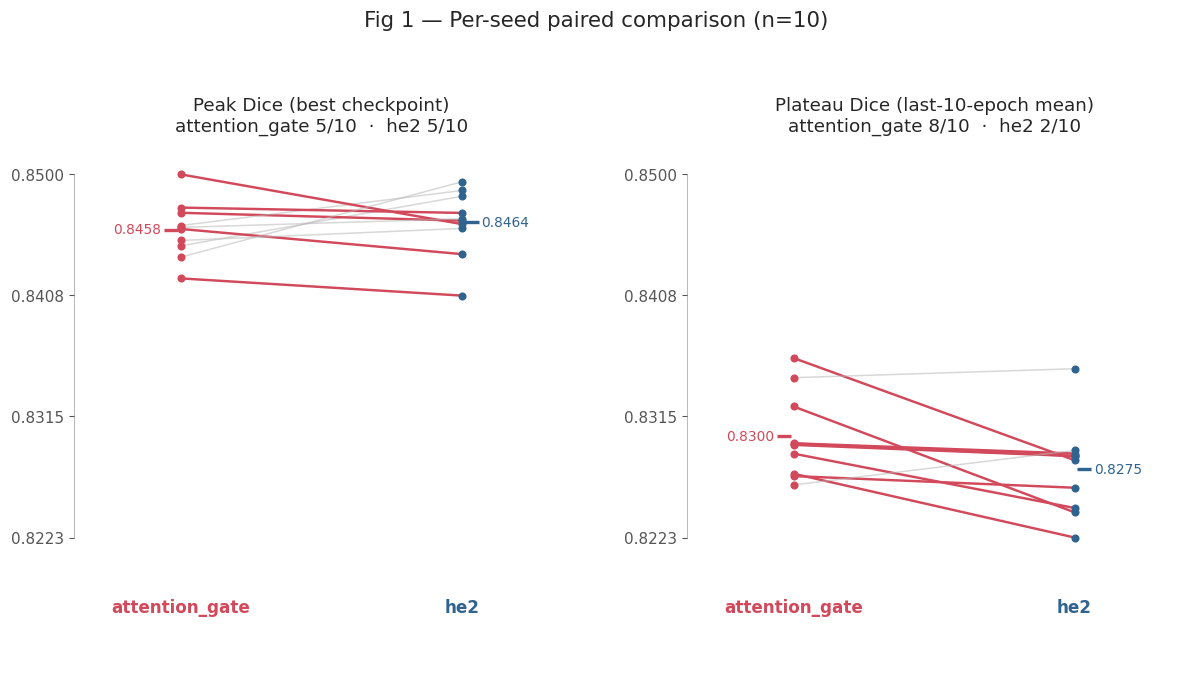

In [5]:
plot_paired_slopegraph(
    runs, SLOPE_METRICS,
    arch_a=AG, arch_b=HE2, seeds=SEEDS, palette=PALETTE,
    title=f'Fig 1 — Per-seed paired comparison (n={N})',
    save_path=FIG_DIR / 'E2_fig1_paired_slopegraph.png',
);

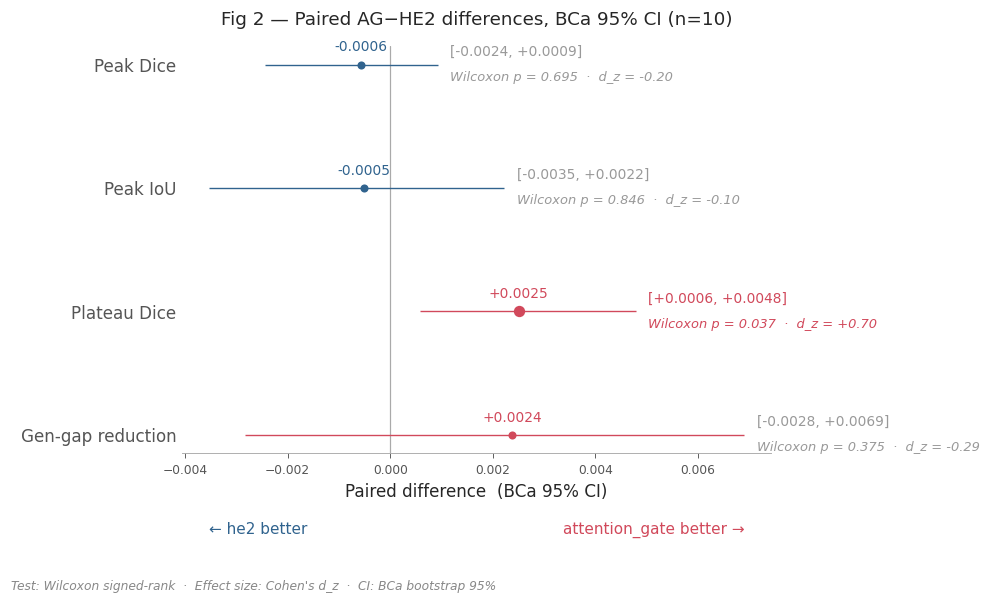

In [6]:
plot_paired_forest(
    results, FOREST_SPECS,
    arch_a=AG, arch_b=HE2, n=N, palette=PALETTE,
    title=f'Fig 2 — Paired AG−HE2 differences, BCa 95% CI (n={N})',
    save_path=FIG_DIR / 'E2_fig2_forest_paired_diff.png',
);

## 5. Decision

> **Lock `classical` encoder + `attention_gate` merge at `lr = 3e-4`.**

| Priority | Criterion | AG | HE2 | Status (n = 10) |
|---|---|---|---|---|
| 1 | **Plateau Dice — *pre-registered primary*** (8/10 seeds) | **0.8300** | 0.8275 | AG **confirmed** — p = 0.037, CI [+0.0006, +0.0048], d_z = +0.70; passes pre-registered primary (k = 1, α = 0.05) ✓ |
| 2 | Peak Dice / IoU | 0.8458 | **0.8464** | tie — Δ ≈ −0.0006, p = 0.70 / 0.85, CI spans 0 |
| 3 | Generalisation gap | 0.092 | 0.094 | tie — p = 0.38, CI spans 0 |
| 4 | Training throughput | 119.7 sps | **135.3 sps** | HE2 **confirmed** — p = 0.002, standalone (k = 1, α = 0.05) ✓ |

**Rationale.** AG wins the one pre-registered model-quality axis (plateau stability); peak accuracy is a dead tie; no secondary metric survives Holm correction. HE2's only confirmed advantage is a 13 % throughput edge